In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict
from model_ranking import (
    load_h5,
    get_output_paths,
    calculate_correlation_statistics,
    scores_to_rank
)

from pathlib import Path


In [2]:
NA_UNet_source_models = {
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
Res_source_models = {
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}

Unetr_source_models = {
    "EPFL": "E_model_Unetr2",
    "Hmito": "Hm_model_Unetr2",
    "Rmito": "Rm_model_Unetr2",
}
Unet_source_models={
    "EPFL": "E_model5",
    "Hmito": "Hm_model4",
    "Rmito": "Rm_model4",
    "VNC": "V_model2",
}

In [6]:
source_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]
target_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]
approach="consistency"
result_folder="P_full"
summary_results_postfix = "_full"
base_dir_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
ccfv_base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/ccfv_scores"
perf_key = "hard_f1"
source_model_types = [
    NA_UNet_source_models, 
    #Res_source_models, 
    Unet_source_models, 
    Unetr_source_models
]

In [14]:
per_target_f1_means: Dict[str, List[float]] = {}
per_target_f1_medians: Dict[str, List[float]]  = {}
per_target_ccfv_scores: Dict[str, List[float]] = {}
per_target_model_names: Dict[str, List[str]] = {}
for target in target_datasets:
    f1_means: List[float] = []
    f1_medians: List[float] = []
    ccfv_scores: List[float] = []
    model_names: List[str] = []
    for model_type in source_model_types:
        sources = list(model_type.keys())
        for source in sources:
            if (target == "VNC") and ("VNC" in sources):
            # remove VNC from sources
                sources.remove("VNC")

            #print(f'{source} -> {target}')
            output_path = get_output_paths(
                source,
                target,
                selected_augmentations={"none": []},
                selected_norms=[None],
                source_model=model_type[source],
                output=f"metric_summary{summary_results_postfix}.h5",
                approach=approach,
                result_folder=result_folder,
                base_dir_path=base_dir_path,
            )
            assert len(output_path) == 1, f"num paths found == {len(output_path)}"
            f1_means.append(load_h5(output_path[0], f"{perf_key}_mean")[1])
            f1_medians.append(load_h5(output_path[0], f"{perf_key}_median")[1])
            ccfv_scores_path = Path(ccfv_base_path) / f"{source}_to_{target}" / model_type[source] /"ccfv_score.npy"
            ccfv_scores.append(np.load(ccfv_scores_path))
            model_names.append(model_type[source])
    per_target_f1_means[target] = f1_means
    per_target_f1_medians[target] = f1_medians
    per_target_ccfv_scores[target] = ccfv_scores
    per_target_model_names[target] = model_names

            


In [ ]:
a = np.array(per_target_ccfv_scores["EPFL"])
a = np.expand_dims

(11,)

In [27]:
target = "EPFL"
kendall_tau, pearson, spearman = calculate_correlation_statistics(
    np.expand_dims(np.array((per_target_ccfv_scores[target])), axis=1),
    np.array((per_target_f1_medians[target])),
)

In [33]:
perf_scores = np.array(per_target_f1_medians[target])
print(perf_scores)
ranked_perf = scores_to_rank(
    perf_scores, ascending=False, tolerance=0
)
print(ranked_perf)
transfer_scores = np.array(per_target_ccfv_scores[target])
print(transfer_scores)
ranked_consis = scores_to_rank(
    transfer_scores, ascending=False, tolerance=0
)
print(ranked_consis)

[0.         0.5159914  0.13405988 0.3819321  0.6027672  0.19602495
 0.50033927 0.69397414 0.39475566]
[9 3 8 6 2 7 4 1 5]
[-5.63145263 -7.0160087  -6.20157714 -6.34505351 -6.85318085 -6.04825547
 -5.45070924 -5.7782693  -5.26848753]
[3 9 6 7 8 5 2 4 1]


In [29]:
kendall_tau.shape

(1, 2)

Target: EPFL
Target: Hmito
Target: Rmito
Target: VNC


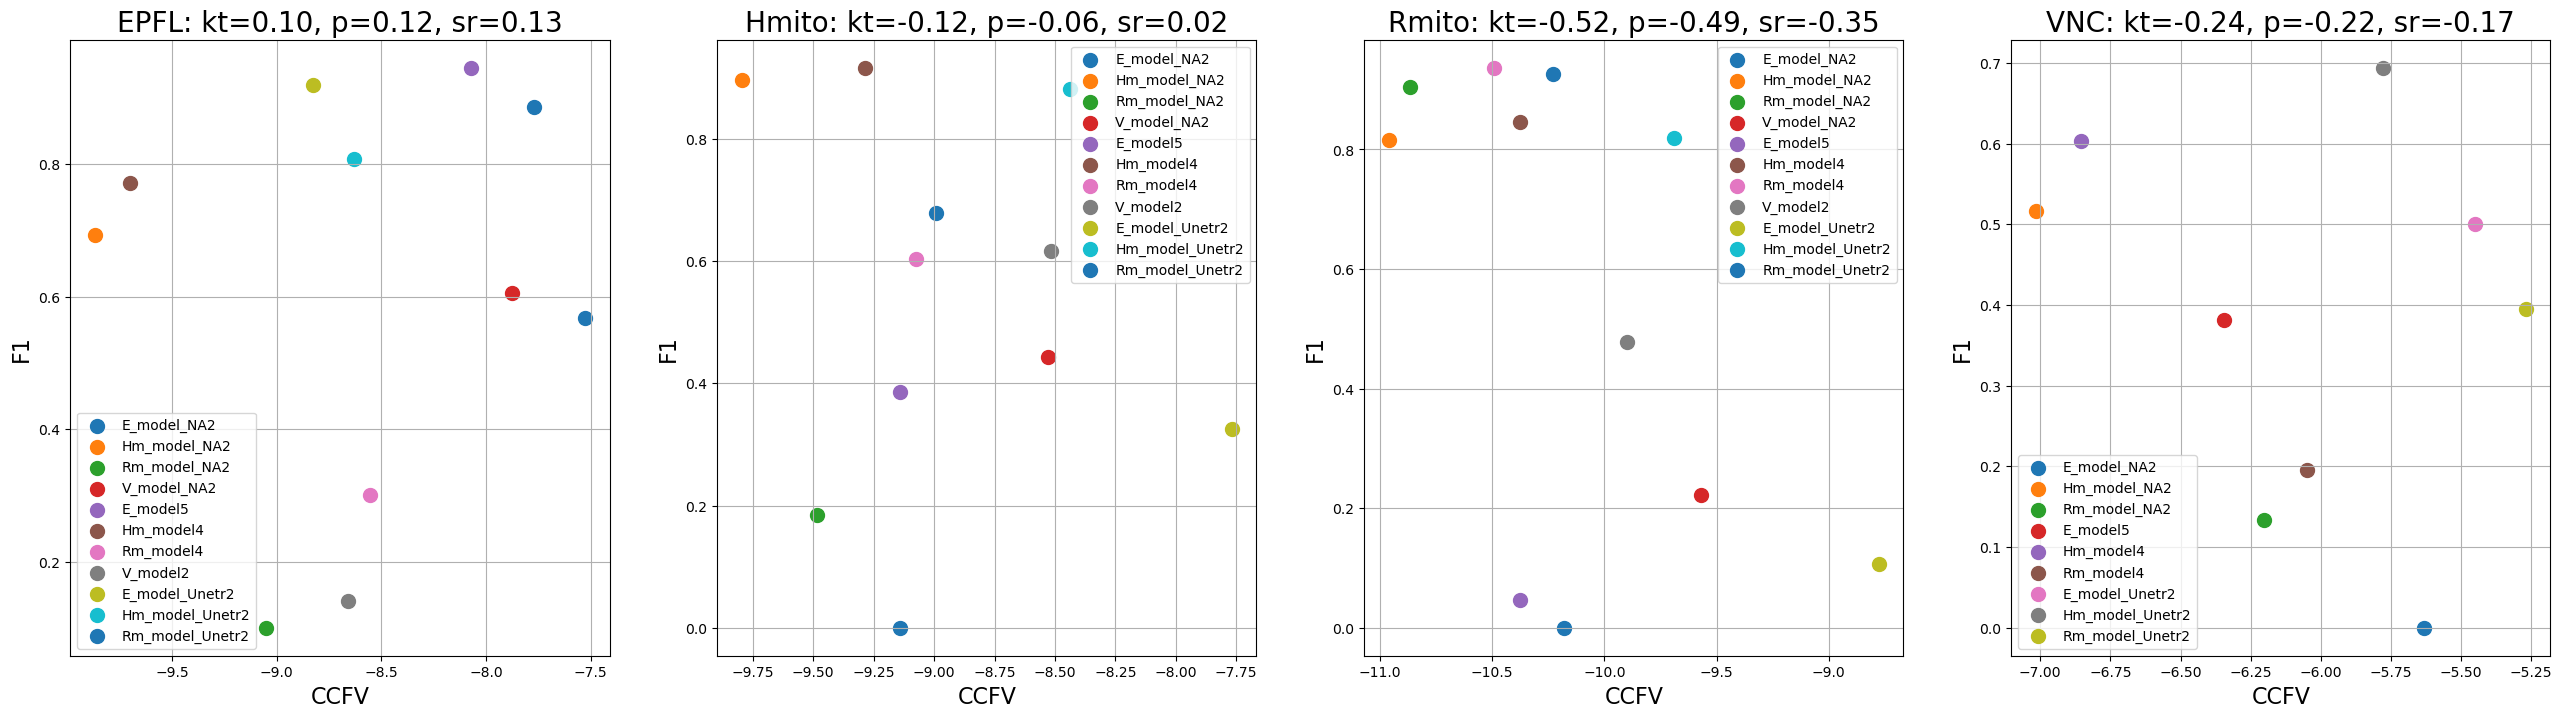

In [37]:
_, axs = plt.subplots(1, 4, figsize=(32, 8))
axs = axs.flatten()
for i, target in enumerate(target_datasets):
    print(f"Target: {target}")
    kendall_tau, pearson, spearman = calculate_correlation_statistics(
        np.expand_dims(np.array((per_target_ccfv_scores[target])), axis=1),
        np.array((per_target_f1_medians[target])),
    )
    for j, model_name in enumerate(per_target_model_names[target]):
        axs[i].scatter(per_target_ccfv_scores[target][j], per_target_f1_medians[target][j], label=model_name, s=100)
    axs[i].set_xlabel("CCFV", fontsize=16)
    axs[i].set_ylabel("F1", fontsize=16)
    axs[i].set_title(f"{target}: kt={kendall_tau[0, 0]:.2f}, p={pearson[0, 0]:.2f}, sr={spearman[0, 0]:.2f}", fontsize=20)
    axs[i].legend()
    axs[i].grid()
plt.show()